The publisher pricing strategy team wants to understand whether more expensive games are associated with better user ratings.

The analysis uses:

* `price` — the listed game price
* `positive_ratings` — the number of positive ratings
* `negative_ratings` — the number of negative ratings

The positive review ratio is defined as:

$$
\frac{\text{positive ratings}}
{\text{positive ratings}+\text{negative ratings}}
$$

Games without any ratings are removed before the positive review ratio is calculated.

The Pearson correlation between price and positive review ratio is calculated across all remaining games. This coefficient measures the direction and strength of the relationship between listed price and user satisfaction.

A positive coefficient would indicate that higher-priced games tend to receive better user ratings, while a negative coefficient would indicate that higher-priced games tend to receive lower ratings.

A scatter plot with a fitted trend line is used to visualize the relationship. The resulting correlation and p-value are reported as the overall evidence for whether a price premium is associated with stronger user satisfaction.

Loading...
Loaded: (27075, 18)
Filtering...
Filtered: (27075, 18)
Computing ratio...
Running Pearson...
Correlation: 0.07645489290365289
P-value: 2.1624296513817798e-36


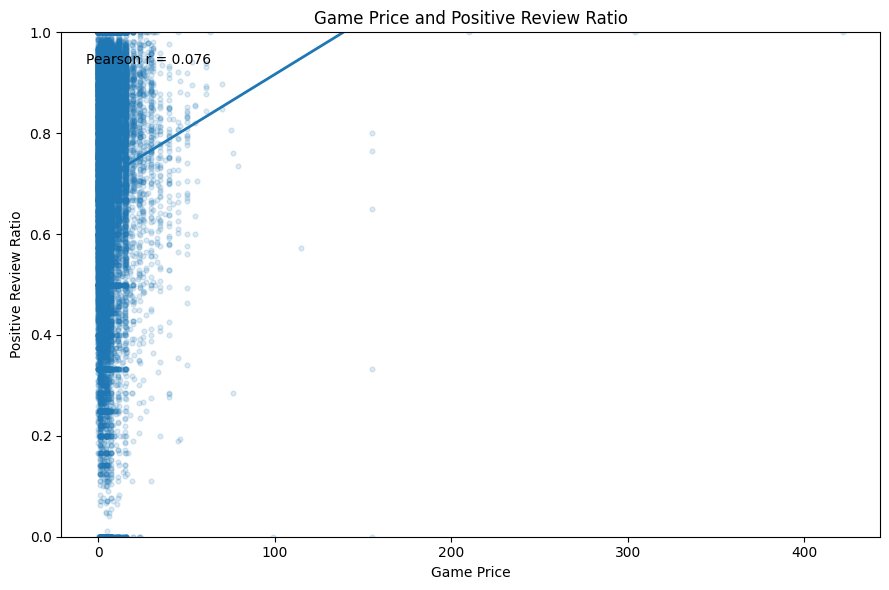

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


STEAM_PATH = "data/steam/steam.csv"


def load_steam(path: str) -> pd.DataFrame:
    """Load the Steam dataset and validate the required columns."""
    file_path = Path(path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    steam = pd.read_csv(file_path)

    required_columns = {
        "price",
        "positive_ratings",
        "negative_ratings",
    }

    missing_columns = required_columns - set(steam.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    steam = steam.copy()

    for column in [
        "price",
        "positive_ratings",
        "negative_ratings",
    ]:
        steam[column] = pd.to_numeric(
            steam[column],
            errors="coerce",
        )

    return steam


print("Loading...")

steam = load_steam(STEAM_PATH)

print("Loaded:", steam.shape)


# Remove rows with missing values in the fields
# required for the correlation.
steam = steam.dropna(
    subset=[
        "price",
        "positive_ratings",
        "negative_ratings",
    ]
).copy()


print("Filtering games without ratings...")

steam["total_ratings"] = (
    steam["positive_ratings"]
    + steam["negative_ratings"]
)

steam = steam[
    steam["total_ratings"] > 0
].copy()

print("Filtered:", steam.shape)


# Calculate positive review ratio.
print("Computing positive review ratio...")

steam["positive_ratio"] = (
    steam["positive_ratings"]
    / steam["total_ratings"]
)


print(
    "Median game price:",
    steam["price"].median(),
)

print(
    "Median positive review ratio:",
    steam["positive_ratio"].median(),
)


# Calculate the Pearson correlation across
# all games with at least one rating.
print("Running Pearson correlation...")

corr, p_value = pearsonr(
    steam["price"],
    steam["positive_ratio"],
)

print(
    "Correlation:",
    corr,
)

print(
    "P-value:",
    p_value,
)


# Sample records for visualization.
plot_data = steam.sample(
    n=min(20_000, len(steam)),
    random_state=42,
)

x = plot_data["price"].to_numpy()
y = plot_data["positive_ratio"].to_numpy()


# Fit a linear trend line to the plotted sample.
slope, intercept = np.polyfit(
    x,
    y,
    1,
)

x_line = np.linspace(
    x.min(),
    x.max(),
    200,
)

y_line = (
    slope * x_line
    + intercept
)


# Visualize the unadjusted relationship.
fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    x,
    y,
    alpha=0.15,
    s=12,
)

ax.plot(
    x_line,
    y_line,
    linewidth=2,
)

ax.set_title(
    "Game Price and Positive Review Ratio"
)

ax.set_xlabel(
    "Game Price"
)

ax.set_ylabel(
    "Positive Review Ratio"
)

ax.set_ylim(
    0,
    1,
)

ax.text(
    0.03,
    0.96,
    f"Pearson r = {corr:.3f}\n"
    f"p = {p_value:.3g}",
    transform=ax.transAxes,
    va="top",
)

plt.tight_layout()
plt.show()


print("\nFinal result:")

print(
    "Correlation between price and "
    "positive review ratio:",
    corr,
)

print(
    "P-value:",
    p_value,
)


if corr > 0:
    direction = "positive"
elif corr < 0:
    direction = "negative"
else:
    direction = "no linear"

print(
    "The analysis found a",
    direction,
    "relationship between game price "
    "and positive review ratio.",
)